# 03 — Moving-Average Timing (the Faber baseline)

**Goal:** replicate the classic trend rule from Mebane Faber's tactical-allocation work:

> If the index is **above** its moving average → hold the S&P 500.
> If the index is **below** its moving average → move to **cash**.

The moving average is just the average price over the last *N* days. Being above it is a simple definition of 'in an uptrend'.

**No look-ahead:** we decide today's position using *yesterday's* signal. The `lagged_signal` function shifts the signal by one day so we never trade on information we could not have had.

In [1]:
# --- standard setup (run me first) ---
import sys, os
# Make the project root importable so `from src import ...` works from notebooks/.
sys.path.insert(0, os.path.abspath(".."))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Setup complete. Project root:", os.path.abspath(".."))

Setup complete. Project root: C:\Users\Taffy Jackson\leveraged-trend-following


In [2]:
from src import data_loader as dl, returns as rt, signals as sg
from src import backtest as bt, metrics as mx, plots as pl, config

underlying, ticker, _ = dl.get_underlying_total_return()
u = rt.simple_returns(underlying)
rf = dl.get_risk_free_daily(u.index)

## The signal, drawn

Shaded red = the index is **below** its 200-day average. Those are the periods the classic rule sits in cash — and the periods our later strategy will try to *leverage* instead.

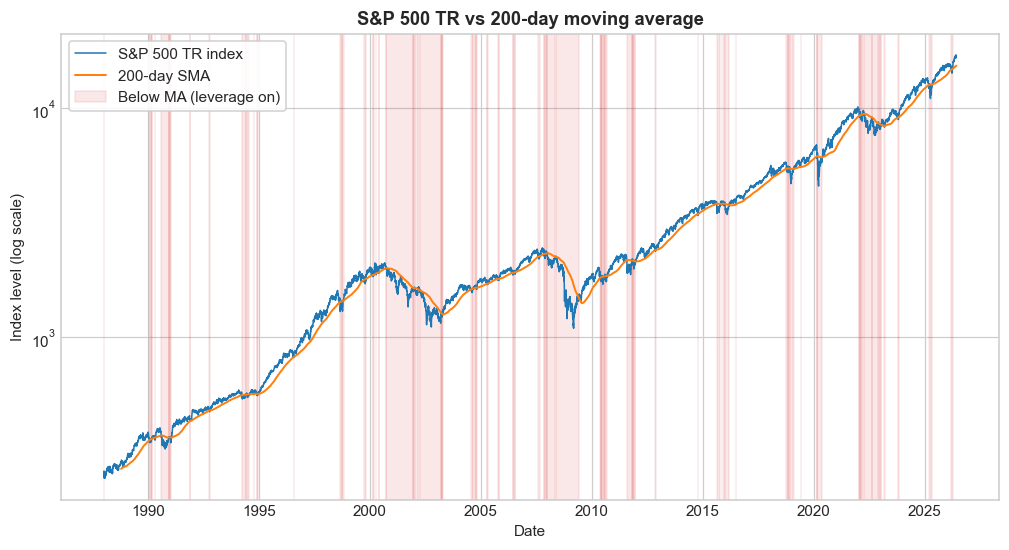

In [3]:
fig = pl.plot_ma_signal(underlying, 200, '02_ma_signal_200d.png')
plt.show()

## Test several moving-average windows

Faber's original rule is monthly (a 10-month average). On daily data, the rough equivalents are ~200–252 days. We test a range and compare each to buy-and-hold. Cash earns the real T-bill rate.

In [4]:
rows = []
for w in config.MA_WINDOWS:
    res = bt.ma_to_cash(underlying, u, w, rf_daily=rf, costs=config.ZERO_COSTS)
    srow = res.summary(rf_daily=rf); srow['window'] = w
    rows.append(srow)
bh = bt.buy_and_hold(u, rf_daily=rf); bhrow = bh.summary(rf_daily=rf)
bhrow['window'] = 'buy&hold'; rows.append(bhrow)
tbl = mx.summary_frame(rows)
tbl[['window','cagr','volatility','sharpe','max_drawdown','calmar','n_switches']]

,window,cagr,volatility,sharpe,max_drawdown,calmar,n_switches
0,50,0.0668,0.1094,0.3836,-0.3543,0.1886,652
1,100,0.0809,0.1130,0.4922,-0.4683,0.1728,425
2,150,0.0888,0.1158,0.5480,-0.2869,0.3096,332
3,200,0.1017,0.1176,0.6434,-0.2055,0.4951,224
4,210,0.0972,0.1178,0.6077,-0.2348,0.4139,220
5,250,0.1002,0.1208,0.6197,-0.2327,0.4305,192
6,252,0.0973,0.1211,0.5973,-0.2748,0.3542,202
7,buy&hold,0.1147,0.1787,0.5356,-0.5525,0.2075,0


**What to notice:** the timing rule usually gives up a little CAGR but *dramatically* cuts volatility and drawdown, so its Sharpe and Calmar are higher. That is the whole appeal of trend-following: similar returns, far less pain. The 200-day window is a sensible, robust middle-of-the-road choice.

## Buy-and-hold vs MA200 → cash

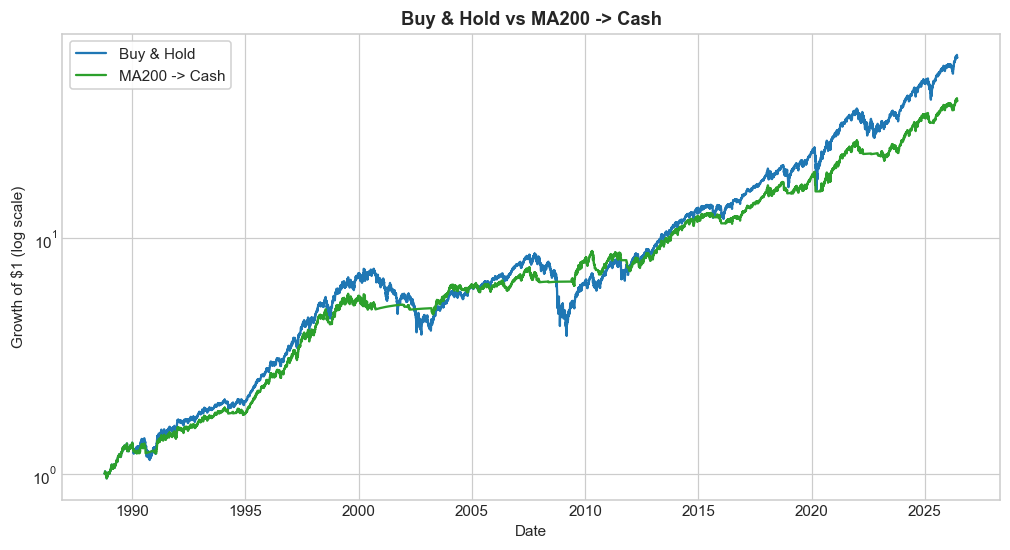

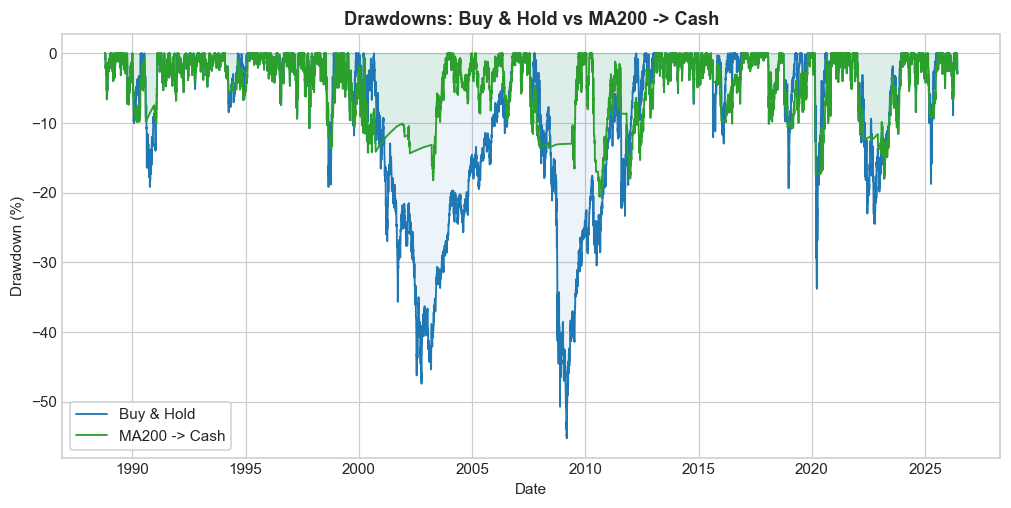

In [5]:
ma200 = bt.ma_to_cash(underlying, u, 200, rf_daily=rf, costs=config.ZERO_COSTS)
comp = {'Buy & Hold': bh.net_returns, 'MA200 -> Cash': ma200.net_returns}
# align to the common window so the comparison is fair
common = bh.net_returns.index.intersection(ma200.net_returns.index)
comp = {k: v.reindex(common).dropna() for k,v in comp.items()}
eq = {k: rt.cumulative_index(v) for k,v in comp.items()}
colors = {'Buy & Hold':'#1f77b4','MA200 -> Cash':'#2ca02c'}
fig = pl.plot_equity_comparison(eq, 'Buy & Hold vs MA200 -> Cash',
    '02_equity_buyhold_vs_timing.png', colors=colors); plt.show()
fig = pl.plot_drawdowns(comp, 'Drawdowns: Buy & Hold vs MA200 -> Cash',
    '02_drawdowns_timing.png', colors=colors); plt.show()

➡️ **Next:** notebook 04 changes one thing — instead of going to *cash* when below the average, we go to *leveraged* S&P 500. This is the central idea of the project.